<center><h1>Zang_Michael_HW2</h1></center>
<br>
<br>

Name: Michael Zang
<br>
Github Username: mzang20
<br>
USC ID: 7754553096

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler

Get the Cycle Power Plant Data Set

In [2]:
features = ["AT", "V", "AP", "RH"]
df = pd.read_excel("data/Folds5x2_pp.xlsx", sheet_name="Sheet1")
display(df.head())

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
print(df.shape)
print(df.isna().sum())

(9568, 5)
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64


9,568 rows and 5 columns. Each row is one hourly observation. `AT`, `V`, `AP`, and `RH` are predictors; `PE` is the power output to predict.

#### ii. pairwise scatterplots of all the varianbles

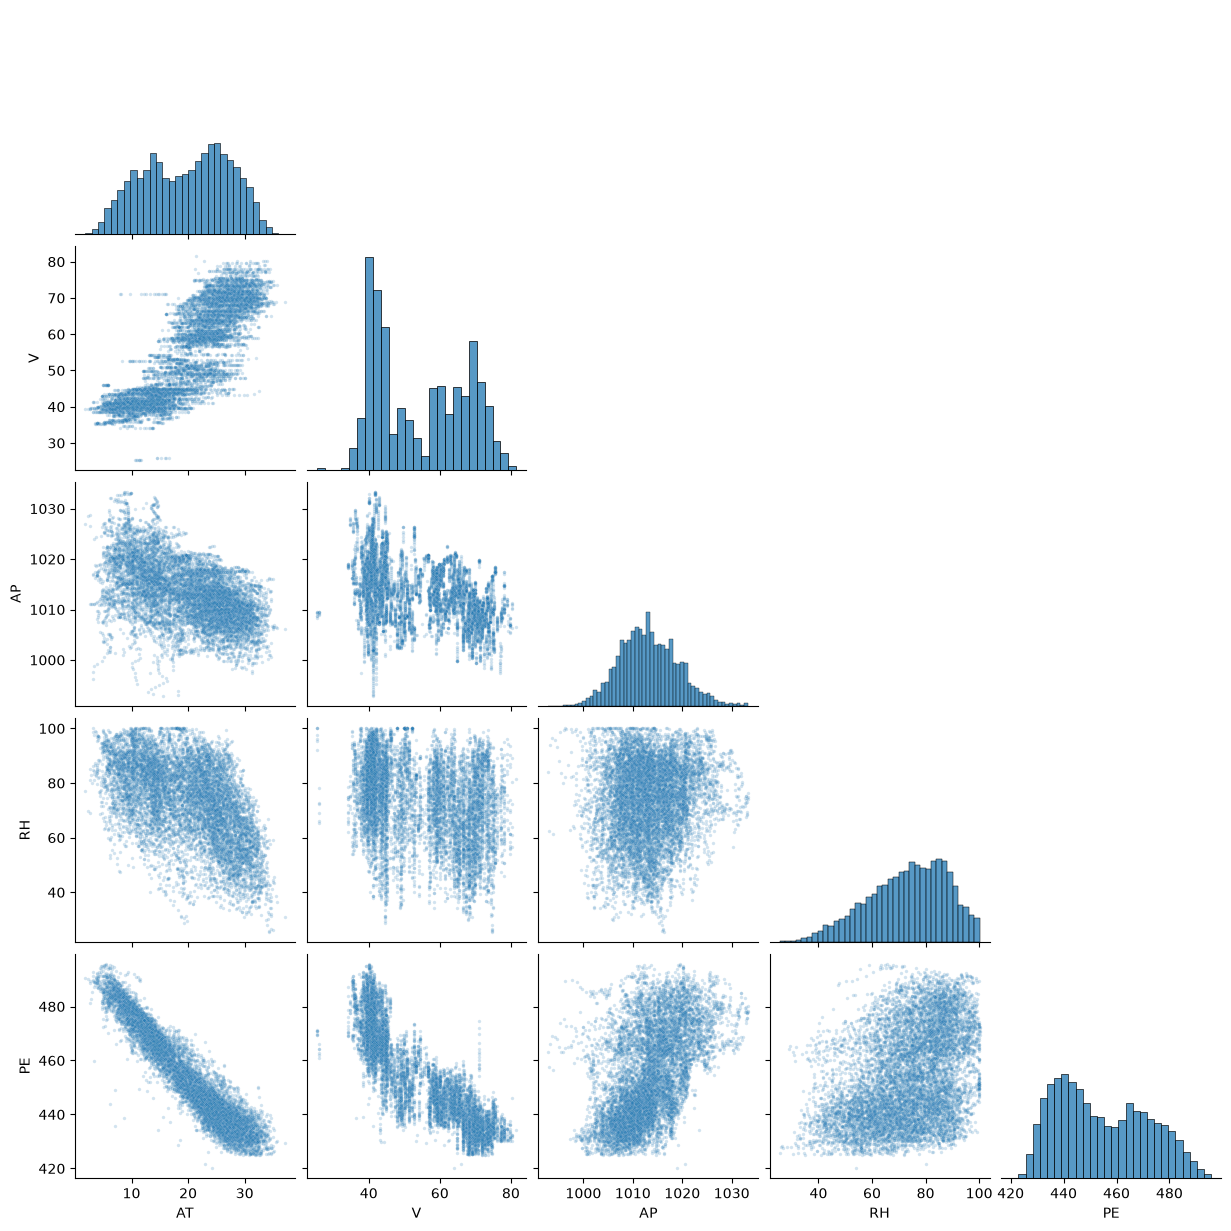

AT   -0.948128
V    -0.869780
AP    0.518429
RH    0.389794
PE    1.000000
Name: PE, dtype: float64

In [4]:
sns.pairplot(df, corner=True, plot_kws={"s": 6, "alpha": 0.2})
plt.show()
display(df.corr(numeric_only=True)["PE"])

`PE` has strong negative relationships with `AT` and `V`, a positive relationship with `AP`, and a smaller positive relationship with `RH`.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
stats = pd.DataFrame({
    "mean": df.mean(), "median": df.median(),
    "range": df.max() - df.min(),
    "Q1": df.quantile(.25), "Q3": df.quantile(.75)
})
stats["IQR"] = stats["Q3"] - stats["Q1"]
display(stats.round(3))

,mean,median,range,Q1,Q3,IQR
AT,19.651,20.345,35.30,13.510,25.72,12.210
V,54.306,52.080,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,74.60,63.328,84.83,21.502
PE,454.365,451.550,75.50,439.750,468.43,28.680


### (c) Simple Linear Regression

,slope,p-value,R²
AT,-2.171320,0.0,0.898948
V,-1.168135,0.0,0.756518
AP,1.489872,0.0,0.268769
RH,0.455650,0.0,0.151939


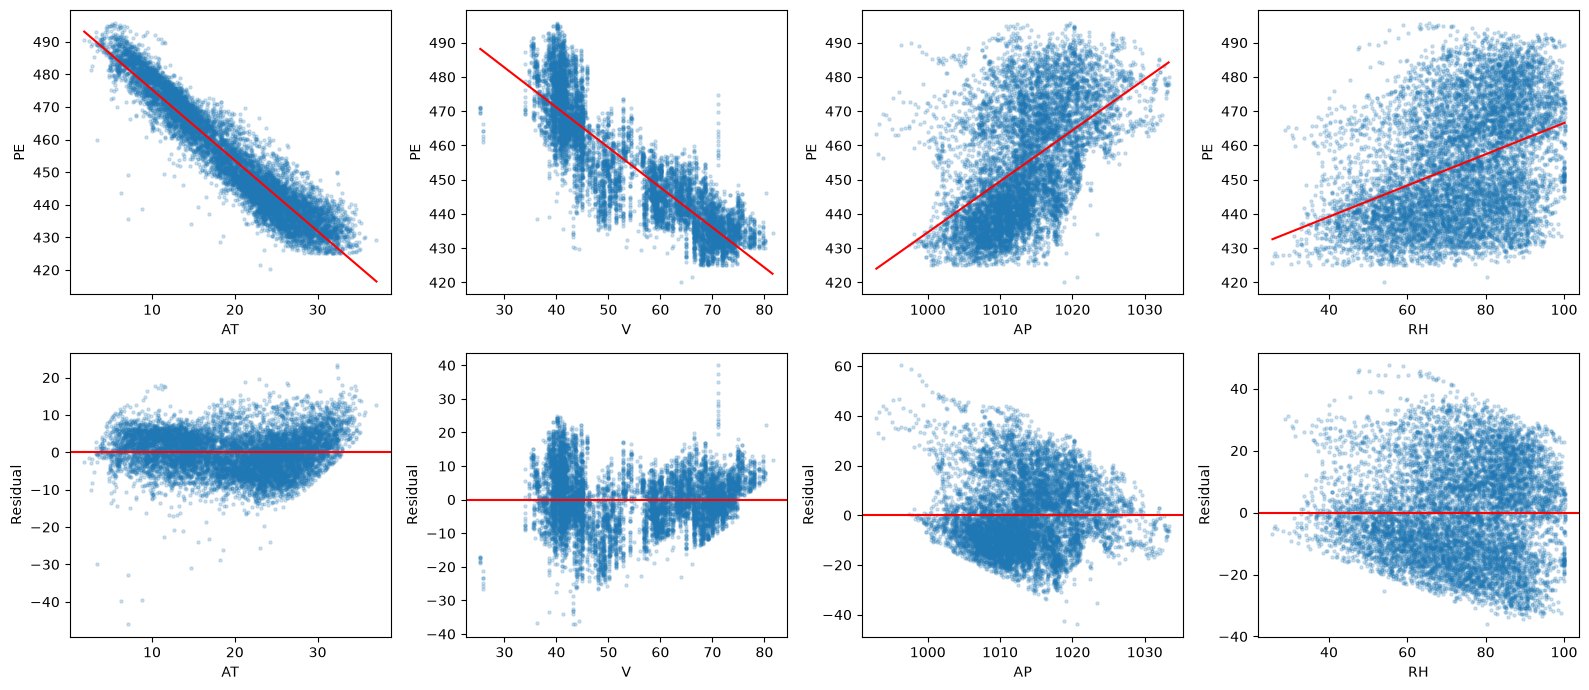

In [6]:
simple = {x: smf.ols(f"PE ~ {x}", data=df).fit() for x in features}
display(pd.DataFrame({x: {"slope": m.params[x], "p-value": m.pvalues[x], "R²": m.rsquared}
                      for x, m in simple.items()}).T)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, x in enumerate(features):
    axes[0, i].scatter(df[x], df.PE, s=5, alpha=.2)
    x_values = np.linspace(df[x].min(), df[x].max(), 100)
    axes[0, i].plot(x_values, simple[x].predict(pd.DataFrame({x: x_values})), color="red")
    axes[0, i].set(xlabel=x, ylabel="PE")
    axes[1, i].scatter(df[x], simple[x].resid, s=5, alpha=.2)
    axes[1, i].axhline(0, color="red")
    axes[1, i].set(xlabel=x, ylabel="Residual")
plt.tight_layout()
plt.show()

All four individual slopes are significant at 0.05. `AT` and `V` have the strongest individual fits. Some residuals are large but they are not data errors so no need to remove.

### (d) Multiple Regression

In [7]:
multiple = smf.ols("PE ~ AT + V + AP + RH", data=df).fit()
display(pd.DataFrame({"coefficient": multiple.params, "p-value": multiple.pvalues}))
print("R²:", multiple.rsquared)

,coefficient,p-value
Intercept,454.609274,0.000000e+00
AT,-1.977513,0.000000e+00
V,-0.233916,4.375305e-215
AP,0.062083,5.507109e-11
RH,-0.158054,3.104584e-293


R²: 0.9286960898122536


All four predictors have p-values below 0.05, so we reject $H_0: \beta_j=0$ for each predictor in the multiple regression.

### (e) 1c Compare to 1d

,simple,multiple
AT,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


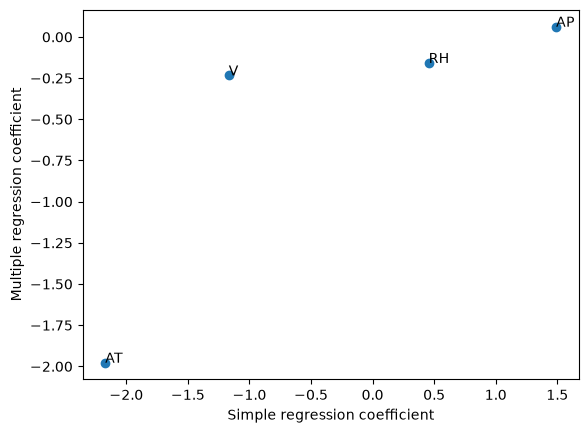

In [8]:
coefs = pd.DataFrame({
    "simple": [simple[x].params[x] for x in features],
    "multiple": multiple.params[features].to_numpy()
}, index=features)
display(coefs)
plt.scatter(coefs.simple, coefs.multiple)
for x, row in coefs.iterrows():
    plt.annotate(x, (row.simple, row.multiple))
plt.xlabel("Simple regression coefficient")
plt.ylabel("Multiple regression coefficient")
plt.show()

The coefficients change when the other predictors are included since the predictors are correlated.

### (f) Nonlinear Association

In [9]:
rows = []
for x in features:
    centered = df.assign(z=df[x] - df[x].mean())
    model = smf.ols("PE ~ z + I(z**2) + I(z**3)", data=centered).fit()
    rows.append({"predictor": x, "quadratic p": model.pvalues["I(z ** 2)"],
                 "cubic p": model.pvalues["I(z ** 3)"],
                 "nonlinearity p": model.compare_f_test(simple[x])[1]})
display(pd.DataFrame(rows).set_index("predictor"))

,quadratic p,cubic p,nonlinearity p
predictor,,,
AT,3.311808e-231,3.652185e-110,3.478379e-285
V,8.977010e-131,1.373489e-02,7.040304e-165
AP,2.192722e-46,2.123338e-67,4.209145e-84
RH,1.013949e-01,1.440279e-05,3.799622e-05


All four predictors show evidence of a nonlinear association. Centering each predictor before taking powers will improve stability.

### (g) Interactions of Predictors

In [10]:
interactions = [f"{a}:{b}" for a, b in combinations(features, 2)]
interaction_model = smf.ols("PE ~ (AT + V + AP + RH)**2", data=df).fit()
display(pd.DataFrame({"coefficient": interaction_model.params[interactions],
                      "p-value": interaction_model.pvalues[interactions]}))

,coefficient,p-value
AT:V,0.020971,3.333358e-117
AT:AP,0.001759,4.520509e-01
AT:RH,-0.005230,1.216944e-10
V:AP,0.006812,2.877026e-07
V:RH,0.000839,8.619366e-02
AP:RH,-0.001612,3.360557e-02


At 0.05, `AT:V`, `AT:RH`, `V:AP`, and `AP:RH` are significant.

### (h) Improvement

In [11]:
train, test = train_test_split(df, train_size=.70, random_state=42)
base = smf.ols("PE ~ AT + V + AP + RH", data=train).fit()
terms = [f"I({x} ** 2)" for x in features] + interactions

# Remove the least significant higher-order term until all remaining
# higher-order terms have p < 0.05. Keep the four parent main effects.
while True:
    expanded = smf.ols("PE ~ " + " + ".join(features + terms), data=train).fit()
    p = expanded.pvalues[terms]
    if p.max() < .05:
        break
    terms.remove(p.idxmax())

def errors(model):
    return {"train MSE": mean_squared_error(train.PE, model.predict(train)),
            "test MSE": mean_squared_error(test.PE, model.predict(test))}

linear_errors = pd.DataFrame({"linear": errors(base), "expanded": errors(expanded)}).T
print("Selected terms:", terms)
display(linear_errors.round(3))

Selected terms: ['I(AT ** 2)', 'I(AP ** 2)', 'I(RH ** 2)', 'AT:V', 'AT:AP', 'AT:RH', 'AP:RH']


,train MSE,test MSE
linear,20.581,21.24
expanded,17.891,18.66


Improves test MSE from 21.240 to 18.660 MW².

### (i) KNN

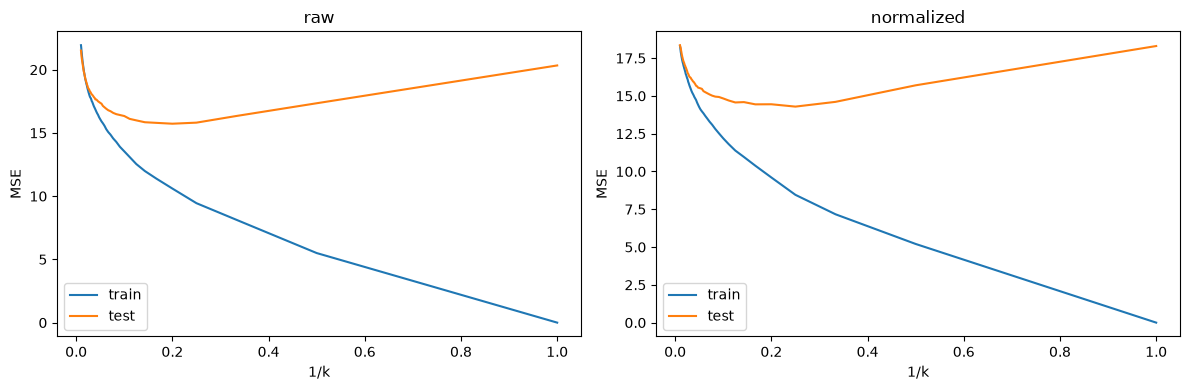

,best k,train MSE,test MSE
raw,5.0,10.601,15.727
normalized,4.0,8.454,14.291


In [12]:
X_train, X_test = train[features], test[features]
y_train, y_test = train.PE, test.PE
scaler = MinMaxScaler().fit(X_train)
data = {"raw": (X_train, X_test),
        "normalized": (scaler.transform(X_train), scaler.transform(X_test))}

knn_results = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, (a, b)) in zip(axes, data.items()):
    train_mse, test_mse = [], []
    for k in range(1, 101):
        model = KNeighborsRegressor(n_neighbors=k).fit(a, y_train)
        train_mse.append(mean_squared_error(y_train, model.predict(a)))
        test_mse.append(mean_squared_error(y_test, model.predict(b)))
    best = int(np.argmin(test_mse) + 1)
    knn_results[name] = {"best k": best, "train MSE": train_mse[best-1],
                         "test MSE": test_mse[best-1]}
    ax.plot(1 / np.arange(1, 101), train_mse, label="train")
    ax.plot(1 / np.arange(1, 101), test_mse, label="test")
    ax.set(xlabel="1/k", ylabel="MSE", title=name)
    ax.legend()
plt.tight_layout()
plt.show()
display(pd.DataFrame(knn_results).T.round(3))

Min–max normalization scales each feature using the training set.

### (j ) Compare KNN and Linear

In [13]:
best_linear = linear_errors["test MSE"].idxmin()
best_knn = min(knn_results, key=lambda name: knn_results[name]["test MSE"])
print(best_linear, "linear model test MSE:", round(linear_errors.loc[best_linear, "test MSE"], 3))
print(best_knn, "KNN test MSE:", round(knn_results[best_knn]["test MSE"], 3))

expanded linear model test MSE: 18.66
normalized KNN test MSE: 14.291


Normalized KNN ($k=4$, test MSE 14.291 MW²) performs better on this split than the linear model (18.660 MW²).

## 2. ISLR 2.4.1

**(a)** Flexible: large $n$ and small $p$ provide enough data to estimate a flexible fit.  
**(b)** Inflexible: since many predictors and few observations, a flexible fit is likely to overfit.  
**(c)** Flexible: it can capture a highly nonlinear relationship.  
**(d)** Inflexible: high error variance makes a flexible fit more likely to chase noise.

## 3. ISLR 2.4.7

| Observation | $(X_1,X_2,X_3)$ | $Y$ | Distance to $(0,0,0)$ |
|---:|:---:|:---:|---:|
| 1 | $(0,3,0)$ | Red | $3$ |
| 2 | $(2,0,0)$ | Red | $2$ |
| 3 | $(0,1,3)$ | Red | $\sqrt{10}$ |
| 4 | $(0,1,2)$ | Green | $\sqrt{5}$ |
| 5 | $(-1,0,1)$ | Green | $\sqrt{2}$ |
| 6 | $(1,1,1)$ | Red | $\sqrt{3}$ |

**(a)** The distances are shown in the table.  
**(b)** For $K=1$, predict **Green** (observation 5 is closest).  
**(c)** For $K=3$, predict **Red** (observations 5, 6, and 2 vote Green, Red, Red).  
**(d)** A **small $K$** generally captures a highly nonlinear boundary better because it uses more local information.